In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import os
import gc
from pathlib import Path
from define_data_and_variables import opes_config, opes_hash, data, version
import json
from matplotlib.collections import LineCollection

In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
# if data["dn"].lower() == "dayu19a":
#     bin_range = (1676, 1727)
#     data_color = "red"
#     data_name = r"$A_1$"
#     ylim_max = 0.4
# elif data["dn"].lower() == "dayu19b":
#     true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
#     bin_range = (1660, 1720)
#     data_color = "orange"
#     data_name = r"$A_2$"
#     ylim_max = 0.15
# if data["dn"].lower() == "dayu19c":
#     true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
#     bin_range = (1680, 1720)
#     data_color = "yellow"
#     data_name = r"$A_3$"
#     ylim_max = 0.25
# print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable
dayu_d18o
[1983.         1974.89278085 1955.98952458 1947.56410581 1936.80199676
 1925.67342961 1922.32178895 1909.68068312 1902.47743075 1886.59813607
 1882.67216141 1879.1114368  1872.09462187 1850.08580362 1835.87934932
 1827.67588506 1813.31256633 1798.09280834 1782.08607244 1773.68949491
 1770.70847325 1764.32889253 1749.89297856 1739.12597794 1725.08923349
 1710.60894853 1704.64387383 1659.17216628 1653.38372703 1635.47828134
 1619.99118576 1604.11446414 1600.15624574 1589.21920743 1572.69499856
 1564.42557322 1560.63362817 1551.47231499 1545.90801501 1518.42658827
 1500.99638681 1480.02100568 1366.49979759 1320.2805739  1310.37792937
 1306.4422984  1292.93313084 1288.46328858 1279.99106453 1268.93377953
 1253.91281246]


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{opes_hash}"
print(output_dir)
hmc_config = opes_config["hmcc"]

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable\output\dayu_d18o\1\3bfc2bcf98


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

(20, 51)


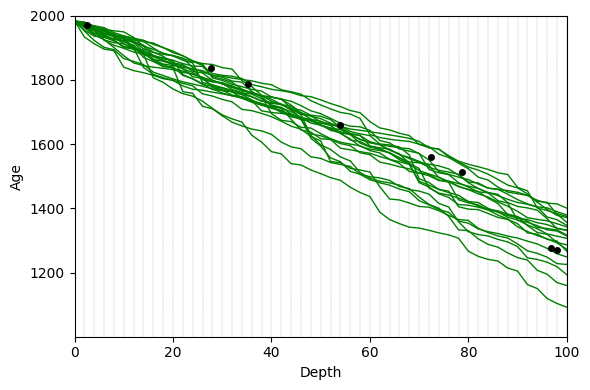

In [5]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [6]:
base_dir = Path.cwd()
df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")
print(df[:, -1, :])

[[   0.          -22.99916194  -43.24210541  -61.13005633  -77.00679184
   -91.1595991  -103.82829559 -115.21826516 -125.51309111 -134.87549214
  -143.44008148 -151.31619833 -158.60056367 -165.36915198 -171.65511787
  -177.4576473  -182.76987087 -187.59550243 -191.95217739 -195.86667465]
 [   0.          -22.99916194  -43.24210541  -61.13005633  -77.00679184
   -91.1595991  -103.82829559 -115.21826516 -125.51309111 -134.87549214
  -143.4400816  -151.31619983 -158.60057132 -165.36916982 -171.65514005
  -177.45766462 -182.76988069 -187.59550696 -191.95217924 -195.86667536]
 [   0.          -22.99916202  -43.24210676  -61.13006456  -77.00681292
   -91.15962516 -103.82831306 -115.21827219 -125.51309294 -134.87549247
  -143.44008164 -151.31619984 -158.60057132 -165.36916982 -171.65514005
  -177.45766462 -182.76988069 -187.59550696 -191.95217924 -195.86667536]
 [   0.          -22.99916203  -43.24210702  -61.13006747  -77.00682554
   -91.15964958 -103.82833709 -115.2182856  -125.51309757 -13

C:\Users\hanna\AppData\Local\Temp\ipykernel_43464\1637702800.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


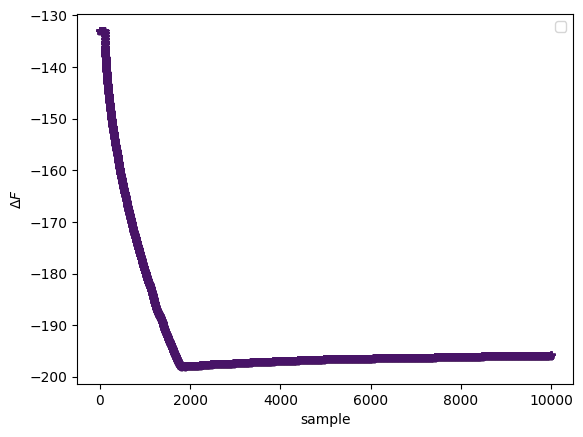

In [7]:
fig, ax = plt.subplots()
ind = -1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, ind])
ax.plot(x[:100000], sample_delta_F[:100000], '*-', color = temp_colors[1])
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


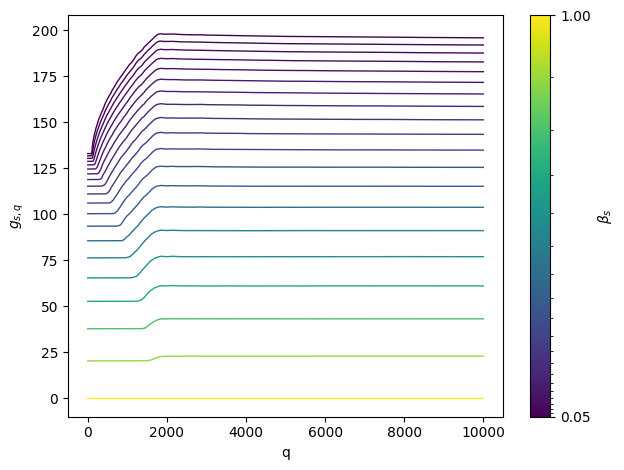

In [8]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:100000], -sample_delta_F[:100000], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"q")
plt.ylabel(r"$g_{s, q}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
plt.savefig(f"{output_dir}/gs.jpg")
plt.show()


In [9]:
# del df
# gc.collect()

In [10]:
cutout = 1000
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [11]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[1906.48003206    2.14290565 2134.26941724 1669.63910589  750.92718104
 1686.74134943 1548.22717428 1745.75575017 1713.2929931  1390.11586576
 1061.39589658 1488.83466477  382.2430713   949.85982745 1676.27841355
 1387.63178894 1872.67734389  376.51102981   97.65215512 2029.05444943]


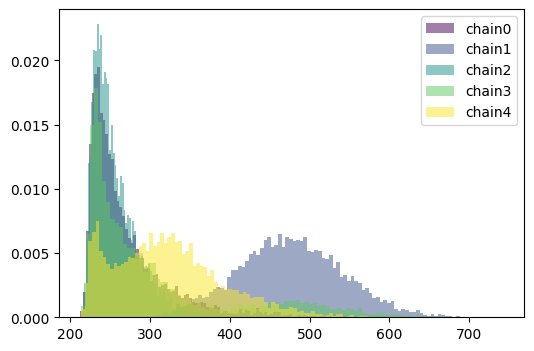

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

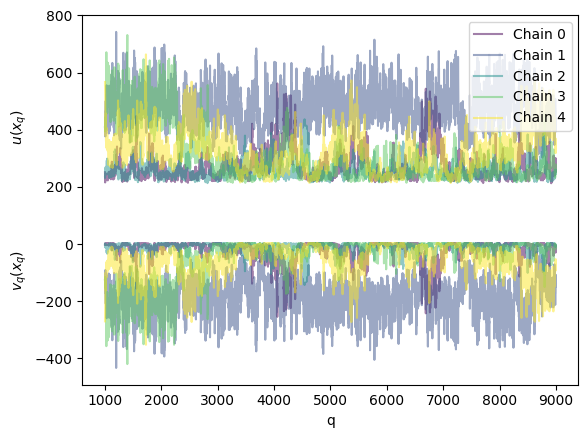

In [13]:
plt.figure()
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), bias_values[i, cutout:100000], color = color_list[i], alpha = 0.5, label = f"Chain {i}")
    plt.plot(np.linspace(cutout, len(bias_values[0, :100000]), len(bias_values[i, cutout:100000])), energy_values[i, cutout:100000], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
plt.legend()
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [14]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [15]:
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(hmc_config["nch"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(hmc_config["nch"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(hmc_config["nch"])]
print(min_energies)

[np.float64(212.74261202249897), np.float64(270.627263769529), np.float64(213.21547489191875), np.float64(214.1704199680346), np.float64(213.83616371898725), np.float64(215.11634438345777), np.float64(212.88626081251513), np.float64(212.94750066125397), np.float64(212.97535767555195), np.float64(213.71366374768502), np.float64(215.5967708218838), np.float64(212.6425587019548), np.float64(211.96950680827302), np.float64(213.4589948980851), np.float64(211.05552379260178), np.float64(212.83015659018295), np.float64(213.46201767037482), np.float64(215.95225221200917), np.float64(221.93156574658423), np.float64(214.4987130557903)]


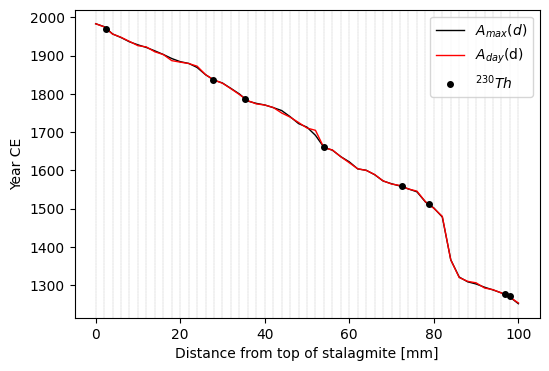

In [16]:
chain = 0
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()



C:\Users\hanna\AppData\Local\Temp\ipykernel_43464\1556759067.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(


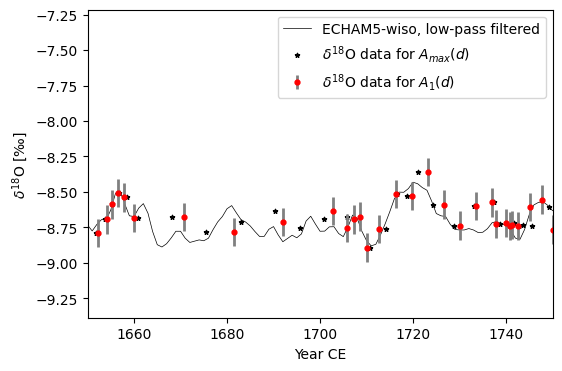

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.errorbar(
    data["d18ota"], 
    data["d18o"], 
    yerr=data["d18os"],       # The error values (can be a constant or array)
    color="red", 
    ecolor = "grey",
    fmt = ".k", 
    markersize=7,                # Makes the stars smaller (default is 6)
    linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    elinewidth=2,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_1(d)$"
)

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"Data regenerated from $A_{close}(d)$"
# )

ax.scatter(
    np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), 
    data["d18o"], 
    # yerr=data["d18os"],       # The error values (can be a constant or array)
    color="black", 
    marker="*", 
    s=10,                # Makes the stars smaller (default is 6)
    # linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    # elinewidth=0.5,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)
# ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
plt.xlim((1650, 1750))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [18]:
resampled_samples = []
weights = np.exp(bias_values)
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=10000,
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 5 done resampling
Chain 6 done resampling
Chain 7 done resampling
Chain 8 done resampling
Chain 9 done resampling
Chain 10 done resampling
Chain 11 done resampling
Chain 12 done resampling
Chain 13 done resampling
Chain 14 done resampling
Chain 15 done resampling
Chain 16 done resampling
Chain 17 done resampling
Chain 18 done resampling
Chain 19 done resampling


In [19]:
chain = 0
index = 25
interesting_depth = index * data["dc"]

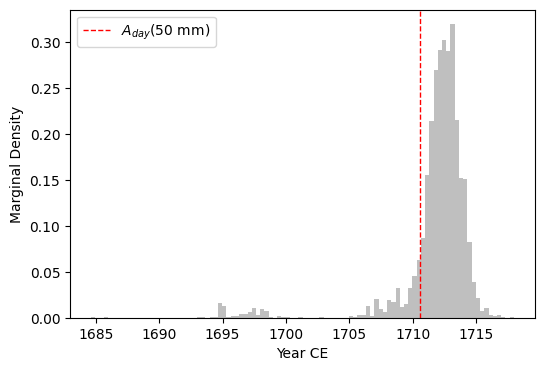

In [20]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

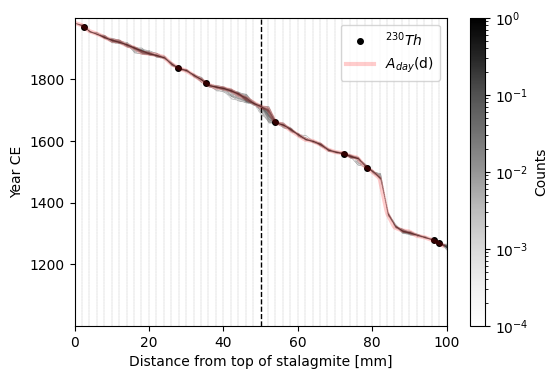

In [21]:
from matplotlib import colors

X = resampled_samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()